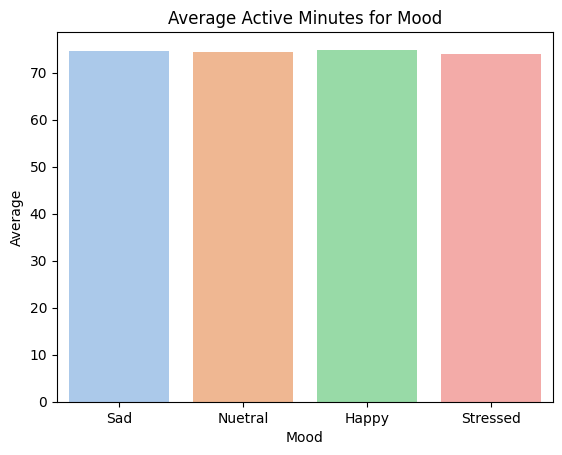

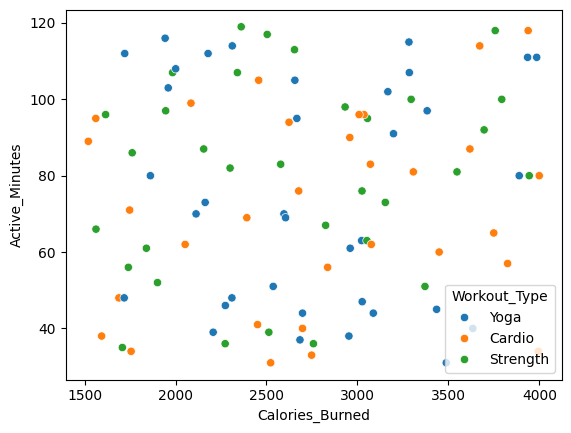

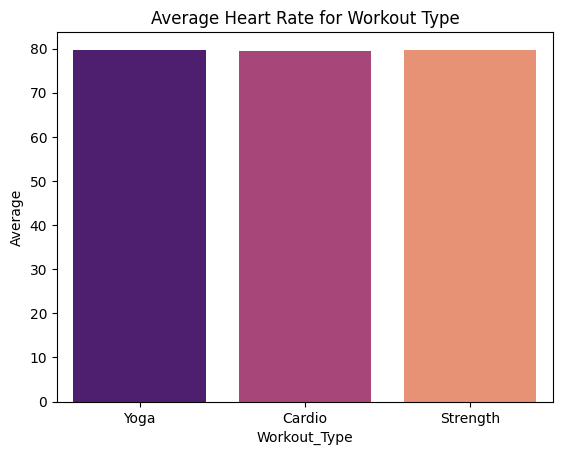

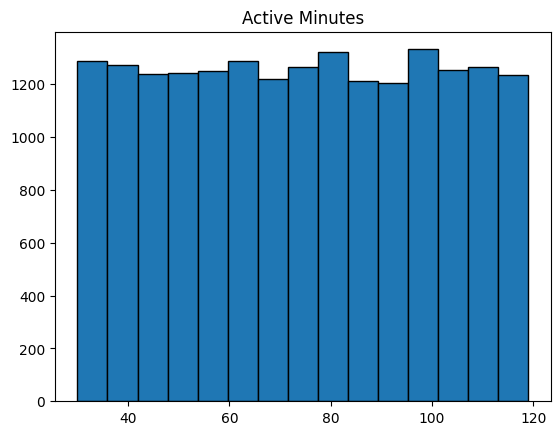

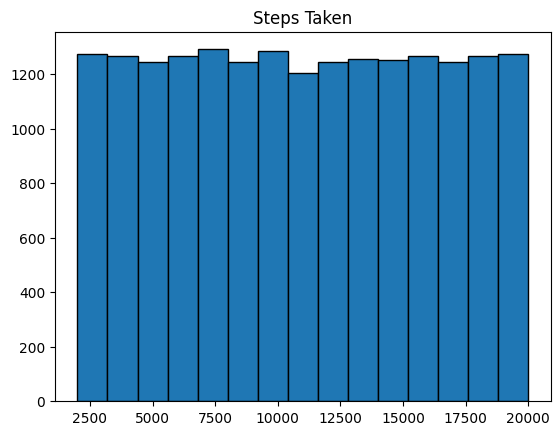

,User_ID,Age,Height (cm),Weight (kg),Steps_Taken,Calories_Burned,Hours_Slept,Water_Intake (Liters),Active_Minutes,Heart_Rate (bpm),Stress_Level (1-10)
User_ID,1.000000,0.164855,-0.047510,-0.102745,-0.001462,0.003316,0.004196,-0.009210,-0.006301,-0.010787,0.003395
Age,0.164855,1.000000,-0.123327,0.003924,-0.002524,0.004672,-0.001244,-0.004047,0.006315,-0.005252,-0.008983
Height (cm),-0.047510,-0.123327,1.000000,-0.045111,-0.008695,0.007365,0.006085,0.002000,-0.010104,0.000088,-0.001821
Weight (kg),-0.102745,0.003924,-0.045111,1.000000,0.009250,0.004445,0.004415,0.000664,0.001133,-0.004339,-0.004025
Steps_Taken,-0.001462,-0.002524,-0.008695,0.009250,1.000000,0.006626,0.000980,0.003763,0.000459,0.005483,0.001241
Calories_Burned,0.003316,0.004672,0.007365,0.004445,0.006626,1.000000,0.009527,0.006076,-0.003144,-0.002404,0.000644
Hours_Slept,0.004196,-0.001244,0.006085,0.004415,0.000980,0.009527,1.000000,-0.005794,-0.000029,0.003159,-0.002227
Water_Intake (Liters),-0.009210,-0.004047,0.002000,0.000664,0.003763,0.006076,-0.005794,1.000000,-0.002399,0.002660,0.001603
Active_Minutes,-0.006301,0.006315,-0.010104,0.001133,0.000459,-0.003144,-0.000029,-0.002399,1.000000,0.008642,0.001612
Heart_Rate (bpm),-0.010787,-0.005252,0.000088,-0.004339,0.005483,-0.002404,0.003159,0.002660,0.008642,1.000000,0.008544


In [2]:

#importing libraries

import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

#=============================================================================================================

#loading dataset

df = pd.read_excel('Fitness_Health_Tracking_Dataset_with_Missing_Values.xlsx')
df_cleaned = df.dropna()

#=============================================================================================================

#Question: How does activity hours affect mood?

#average activity minutes based on mood bar graph

def getAverage(mood):# gets average minutes of every mood to display in bar graph
    total = 0 #gets average minutes of every mood to display in bar graph
    i = 0 #variable to hold all heart rates added together
    array = df_cleaned[['Mood', 'Active_Minutes']].to_numpy() #only using the two columns needed
    for value in array: #iterating through array
        if value[0] == mood: #finding correct workout
            minutes = int(value[1]) #minutes
            total = total + minutes #total minutes of all people
            i = i + 1 #counting how many people
    if i == 0: #does not allow division by zero
        return 0
    average = total/i
    return average

#getting all averages
sad_average = getAverage('Sad')
nuetral_average = (getAverage('Neutral'))
happy_average = (getAverage('Happy'))
stressed_average = (getAverage('Stressed'))

#putting data into new dataframe for graphing
df_average_mood = pd.DataFrame({
    'Mood': ['Sad', 'Nuetral', 'Happy', 'Stressed'],
    'Average': [sad_average, nuetral_average, happy_average, stressed_average]
})

#plot and display
sns.barplot(data=df_average_mood, x='Mood', y='Average', hue='Mood', palette='pastel')
plt.title("Average Active Minutes for Mood")
plt.show()

#=============================================================================================================

#Question: How does workout type affect calories burned?

sns.scatterplot(df_cleaned.head(100), x='Calories_Burned', y='Active_Minutes', hue='Workout_Type')
plt.show()

#=============================================================================================================

#Question: How does workout type affect heartrate?

def getAverageHeartRate(workout): #gets average minutes of every mood to display in bar graph
    total = 0 #variable to hold all heart rates added together
    i = 0 #variable to count how many people in total
    array = df_cleaned[['Workout_Type', 'Heart_Rate (bpm)']].to_numpy() #only using the two columns needed
    for value in array: #iterating through array
        if value[0] == workout: #finding correct workout
            heart_rate = int(value[1]) #heart rate 
            total = total + heart_rate #adding all together
            i = i + 1 #counting how many people
    if i == 0: #does not allow division by zero
        return 0
    average = total/i
    return average

#getting all averages
yoga_average = getAverageHeartRate('Yoga')
cardio_average = getAverageHeartRate('Cardio')
strength_average = getAverageHeartRate('Strength')

#putting data into new dataframe for graphing
df_average_workout = pd.DataFrame({
    'Workout_Type': ['Yoga', 'Cardio', 'Strength'],
    'Average': [yoga_average, cardio_average, strength_average]
})

#plot and display
sns.barplot(data=df_average_workout, x='Workout_Type', y='Average', hue='Workout_Type', palette='magma')
plt.title("Average Heart Rate for Workout Type")
plt.show()

#=============================================================================================================


#Active Minutes

plt.hist(data=df_cleaned, x='Active_Minutes', edgecolor='black', bins=15)
plt.title('Active Minutes')
plt.show()

#=============================================================================================================

#Steps Taken

plt.hist(data=df_cleaned, x='Steps_Taken', edgecolor='black', bins=15)
plt.title('Steps Taken')
plt.show()

#=============================================================================================================

#This further proves that this is synthetic data

# Check correlations for numeric columns
numeric_df = df.select_dtypes(include='number')
corr = numeric_df.corr()
corr

#=============================================================================================================





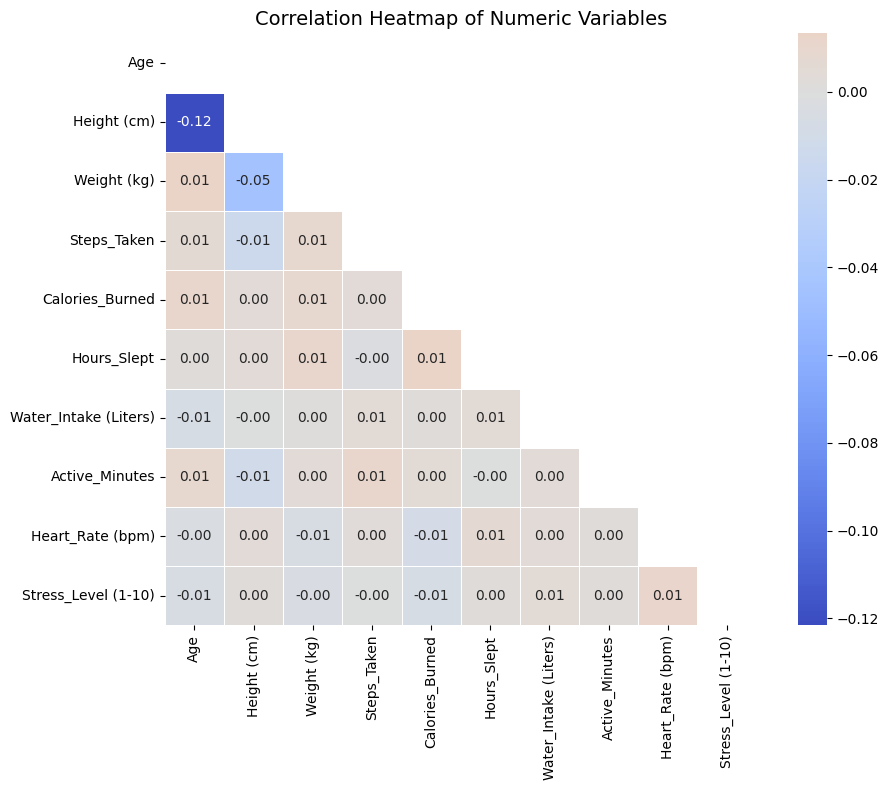

Top 10 Pairwise Correlations (by absolute value):
      Variable_1          Variable_2  Correlation
             Age         Height (cm)    -0.121567
     Height (cm)         Weight (kg)    -0.045098
     Height (cm)         Steps_Taken    -0.014677
 Calories_Burned         Hours_Slept     0.013365
             Age         Weight (kg)     0.013179
Heart_Rate (bpm) Stress_Level (1-10)     0.011811
  Active_Minutes         Steps_Taken     0.011077
  Active_Minutes         Height (cm)    -0.010920
     Hours_Slept         Weight (kg)     0.010477
             Age     Calories_Burned     0.010364


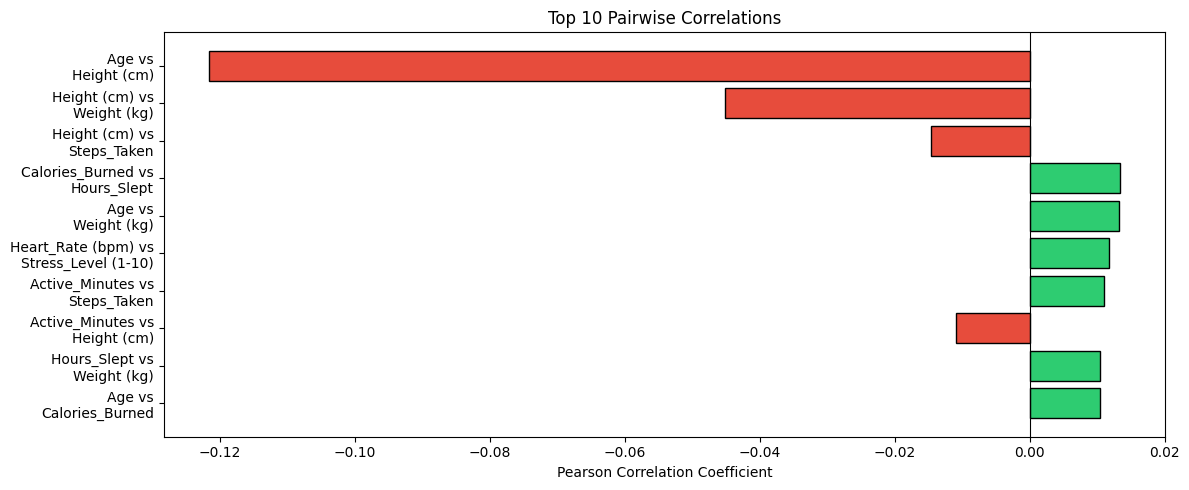


One-Way ANOVA — Workout Type vs Numeric Variables
Variable                        F-statistic    p-value   Significant?
----------------------------------------------------------------------
Age                                  1.7832     0.1681             No
Height (cm)                          1.5161     0.2196             No
Weight (kg)                          0.2775     0.7577             No
Steps_Taken                          0.7209     0.4863             No
Calories_Burned                      1.1202     0.3262             No
Hours_Slept                          0.0900     0.9139             No
Water_Intake (Liters)                2.6453     0.0710             No
Active_Minutes                       0.0506     0.9506             No
Heart_Rate (bpm)                     1.1659     0.3117             No
Stress_Level (1-10)                  1.5264     0.2174             No

One-Way ANOVA — Mood vs Numeric Variables
Variable                        F-statistic    p-value   Signific

In [3]:

#=============================================================================================================

# CORRELATION ANALYSIS
# This section performs a full correlation analysis across all numeric variables.
# Since this is synthetic data, most correlations are near zero — this is expected
# and is itself a meaningful finding.

from scipy import stats

# Drop User_ID — it's an identifier, not a meaningful variable
numeric_df = df_cleaned.select_dtypes(include='number').drop(columns=['User_ID'])

#=============================================================================================================

# Heatmap of all numeric correlations

plt.figure(figsize=(10, 8))
corr_matrix = numeric_df.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # hide upper triangle (duplicate)
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap of Numeric Variables', fontsize=14)
plt.tight_layout()
plt.show()

#=============================================================================================================

# Top pairwise Pearson correlations (excluding self-correlations)

corr_unstacked = corr_matrix.unstack()
corr_pairs = (
    corr_unstacked[corr_unstacked < 1.0]  # drop self-correlations
    .reset_index()
)
corr_pairs.columns = ['Variable_1', 'Variable_2', 'Correlation']

# Keep only one direction (e.g., A-B not B-A)
corr_pairs = corr_pairs[corr_pairs['Variable_1'] < corr_pairs['Variable_2']].copy()
corr_pairs['Abs_Correlation'] = corr_pairs['Correlation'].abs()
corr_pairs_sorted = corr_pairs.sort_values('Abs_Correlation', ascending=False).reset_index(drop=True)

print("Top 10 Pairwise Correlations (by absolute value):")
print(corr_pairs_sorted[['Variable_1', 'Variable_2', 'Correlation']].head(10).to_string(index=False))

#=============================================================================================================

# Bar chart of top correlations

top_n = corr_pairs_sorted.head(10).copy()
top_n['Pair'] = top_n['Variable_1'] + ' vs\n' + top_n['Variable_2']

colors = ['#e74c3c' if c < 0 else '#2ecc71' for c in top_n['Correlation']]

plt.figure(figsize=(12, 5))
bars = plt.barh(top_n['Pair'][::-1], top_n['Correlation'][::-1], color=colors[::-1], edgecolor='black')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson Correlation Coefficient')
plt.title('Top 10 Pairwise Correlations')
plt.tight_layout()
plt.show()

#=============================================================================================================

# ANOVA: Does Workout Type significantly affect any numeric variable?

print("\nOne-Way ANOVA — Workout Type vs Numeric Variables")
print(f"{'Variable':<30} {'F-statistic':>12} {'p-value':>10} {'Significant?':>14}")
print("-" * 70)
for col in numeric_df.columns:
    groups = [grp[col].values for _, grp in df_cleaned.groupby('Workout_Type')]
    f, p = stats.f_oneway(*groups)
    sig = 'Yes' if p < 0.05 else 'No'
    print(f"{col:<30} {f:>12.4f} {p:>10.4f} {sig:>14}")

#=============================================================================================================

# ANOVA: Does Mood significantly affect any numeric variable?

print("\nOne-Way ANOVA — Mood vs Numeric Variables")
print(f"{'Variable':<30} {'F-statistic':>12} {'p-value':>10} {'Significant?':>14}")
print("-" * 70)
for col in numeric_df.columns:
    groups = [grp[col].values for _, grp in df_cleaned.groupby('Mood')]
    f, p = stats.f_oneway(*groups)
    sig = 'Yes' if p < 0.05 else 'No'
    print(f"{col:<30} {f:>12.4f} {p:>10.4f} {sig:>14}")

#=============================================================================================================

# SUMMARY: Key findings

print("\n=== CORRELATION SUMMARY ===")
print(f"Total numeric variable pairs analysed: {len(corr_pairs_sorted)}")
strong = corr_pairs_sorted[corr_pairs_sorted['Abs_Correlation'] >= 0.3]
moderate = corr_pairs_sorted[(corr_pairs_sorted['Abs_Correlation'] >= 0.1) & (corr_pairs_sorted['Abs_Correlation'] < 0.3)]
weak = corr_pairs_sorted[corr_pairs_sorted['Abs_Correlation'] < 0.1]
print(f"  Strong correlations  (|r| >= 0.3): {len(strong)}")
print(f"  Moderate correlations (0.1 <= |r| < 0.3): {len(moderate)}")
print(f"  Weak correlations    (|r| < 0.1): {len(weak)}")
print()
print("Finding: Nearly all correlations are near zero. This confirms the dataset")
print("is synthetically generated with no meaningful real-world relationships")
print("embedded between variables.")

#=============================================================================================================
